# PROJET ML — CLASSIFICATION DE VIDÉOS YOUTUBE *TRENDING*

**Dataset Kaggle**: https://www.kaggle.com/datasets/datasnaek/youtube-new

**Objectif**: Développer un classificateur pour prédire si une vidéo YouTube deviendra *trending*.

> Ce notebook est conçu pour être complété. Chaque section contient des consignes détaillées et des zones de code à compléter.


## 1. Importation des librairies

**Consigne 1.1 — Importez toutes les librairies nécessaires**
- `pandas`, `numpy` pour la manipulation de données  
- `matplotlib.pyplot`, `seaborn` pour la visualisation  
- `sklearn` pour le machine learning  
- `warnings` pour supprimer les avertissements

In [225]:
# VOTRE CODE ICI - Section 1.1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
print(os.getcwd())
warnings.filterwarnings('ignore')

/home/emese/Briefs/youtube_ML


## 2. Chargement et exploration des données

**Consigne 2.1 — Chargement des données**
- Chargez le fichier `USvideos.csv` avec pandas  
- Affichez les 5 premières lignes  
- Affichez les informations générales (`info()`, `shape`, `describe()`)

*Aide* :
- Utilisez `pd.read_csv()` avec `encoding='utf-8'`
- `.info()` donne les types de colonnes et valeurs non-nulles
- `.describe()` donne les statistiques descriptives

In [226]:
df = pd.read_csv('/home/emese/Briefs/youtube_ML/data/USvideos.csv', encoding='utf-8')

print("First lines")
display(df.head(5))

print("\nGeneral information")

display(df.info())
display(df.describe(include='all').transpose())

First lines


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John..."
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...
3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13T11:00:04.000Z,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...
4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...



General information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40949 entries, 0 to 40948
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   video_id                40949 non-null  object
 1   trending_date           40949 non-null  object
 2   title                   40949 non-null  object
 3   channel_title           40949 non-null  object
 4   category_id             40949 non-null  int64 
 5   publish_time            40949 non-null  object
 6   tags                    40949 non-null  object
 7   views                   40949 non-null  int64 
 8   likes                   40949 non-null  int64 
 9   dislikes                40949 non-null  int64 
 10  comment_count           40949 non-null  int64 
 11  thumbnail_link          40949 non-null  object
 12  comments_disabled       40949 non-null  bool  
 13  ratings_disabled        40949 non-null  bool  
 14  video_error_or_removed  40949 non

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
video_id,40949,6351,j4KvrAUjn6c,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trending_date,40949,205,17.14.11,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,40949,6455,WE MADE OUR MOM CRY...HER DREAM CAME TRUE!,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
channel_title,40949,2207,ESPN,203,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category_id,40949.0,NaN,NaN,NaN,19.972429,7.568327,1.0,17.0,24.0,25.0,43.0
publish_time,40949,6269,2018-05-18T14:00:04.000Z,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tags,40949,6055,[none],1535,NaN,NaN,NaN,NaN,NaN,NaN,NaN
views,40949.0,NaN,NaN,NaN,2360784.638257,7394113.759704,549.0,242329.0,681861.0,1823157.0,225211923.0
likes,40949.0,NaN,NaN,NaN,74266.702435,228885.338209,0.0,5424.0,18091.0,55417.0,5613827.0
dislikes,40949.0,NaN,NaN,NaN,3711.400889,29029.705945,0.0,202.0,631.0,1938.0,1674420.0


**Consigne 2.2 — Analyse des valeurs manquantes**  
- Comptez les valeurs manquantes par colonne  
- Identifiez les colonnes avec le plus de valeurs manquantes  
- Affichez le pourcentage de valeurs manquantes

In [227]:
# VOTRE CODE ICI - Section 2.2

missing = df.isnull().sum()
pct_missing = (missing / len(df)) * 100

print("Valeurs manquantes (nombre):")
display(missing)
print("\nValeurs manquantes (pourcentage):")
display(pct_missing)

Valeurs manquantes (nombre):


video_id                    0
trending_date               0
title                       0
channel_title               0
category_id                 0
publish_time                0
tags                        0
views                       0
likes                       0
dislikes                    0
comment_count               0
thumbnail_link              0
comments_disabled           0
ratings_disabled            0
video_error_or_removed      0
description               570
dtype: int64


Valeurs manquantes (pourcentage):


video_id                  0.000000
trending_date             0.000000
title                     0.000000
channel_title             0.000000
category_id               0.000000
publish_time              0.000000
tags                      0.000000
views                     0.000000
likes                     0.000000
dislikes                  0.000000
comment_count             0.000000
thumbnail_link            0.000000
comments_disabled         0.000000
ratings_disabled          0.000000
video_error_or_removed    0.000000
description               1.391975
dtype: float64

**Consigne 2.3 — Exploration des catégories**  
- Chargez le fichier JSON des catégories (`US_category_id.json`)  
- Fusionnez avec le DataFrame principal  
- Affichez la distribution des catégories

*Aide* : La structure JSON est du type:  
`{"items": [{"id": "1", "snippet": {"title": "Film & Animation"}}, ...]}`

In [228]:
# VOTRE CODE ICI - Section 2.3
import pandas as pd
import json

categories_raw = pd.read_json("/home/emese/Briefs/youtube_ML/data/US_category_id.json")

#display(categories_raw)

items = categories_raw['items'].tolist()

category_dict = {}
for item in items:
    key = int(item['id'])
    value = item['snippet']['title']

    category_dict[key]=value

display(category_dict)

# category_dict = {int(item['id']): item['snippet']['title'] for item in items}

cat_df = pd.Series(category_dict).reset_index()
cat_df.columns = ['category_id','category_title']

display(cat_df)

# cat_df = pd.DataFrame(list(category_dict.items()), columns=['category_id', 'category_title'])

df_merged = pd.merge(df, cat_df, how="left", on='category_id')

# df_merged = df.merge(cat_df, how='left', left_on='category_id', right_on='category_id')

print("Distribution des catégories:")
display(df_merged['category_title'].value_counts().to_frame('count'))


{1: 'Film & Animation',
 2: 'Autos & Vehicles',
 10: 'Music',
 15: 'Pets & Animals',
 17: 'Sports',
 18: 'Short Movies',
 19: 'Travel & Events',
 20: 'Gaming',
 21: 'Videoblogging',
 22: 'People & Blogs',
 23: 'Comedy',
 24: 'Entertainment',
 25: 'News & Politics',
 26: 'Howto & Style',
 27: 'Education',
 28: 'Science & Technology',
 29: 'Nonprofits & Activism',
 30: 'Movies',
 31: 'Anime/Animation',
 32: 'Action/Adventure',
 33: 'Classics',
 34: 'Comedy',
 35: 'Documentary',
 36: 'Drama',
 37: 'Family',
 38: 'Foreign',
 39: 'Horror',
 40: 'Sci-Fi/Fantasy',
 41: 'Thriller',
 42: 'Shorts',
 43: 'Shows',
 44: 'Trailers'}

,category_id,category_title
0,1,Film & Animation
1,2,Autos & Vehicles
2,10,Music
3,15,Pets & Animals
4,17,Sports
5,18,Short Movies
6,19,Travel & Events
7,20,Gaming
8,21,Videoblogging
9,22,People & Blogs


Distribution des catégories:


,count
category_title,
Entertainment,9964
Music,6472
Howto & Style,4146
Comedy,3457
People & Blogs,3210
News & Politics,2487
Science & Technology,2401
Film & Animation,2345
Sports,2174


In [229]:
df_merged['category_title'].value_counts(normalize=True)*100

counts =  df_merged['category_title'].value_counts()
percentages = df_merged['category_title'].value_counts(normalize=True)*100
distribution = pd.concat([counts, percentages], axis=1)
distribution.columns = ["count", "percentage"]

display(distribution)


,count,percentage
category_title,,
Entertainment,9964,24.332707
Music,6472,15.805026
Howto & Style,4146,10.124789
Comedy,3457,8.442209
People & Blogs,3210,7.839019
News & Politics,2487,6.073408
Science & Technology,2401,5.863391
Film & Animation,2345,5.726636
Sports,2174,5.309043


## 3. Nettoyage des données

**Consigne 3.1 — Nettoyage des données**
- Supprimez les doublons basés sur `video_id`  
- Gérez les valeurs manquantes dans `description` (remplacez par string vide)  
- Convertissez `publish_time` en datetime  
- Supprimez les lignes avec des valeurs aberrantes (ex: `views` négatives)

In [230]:
# VOTRE CODE ICI - Section 3.1
# df_clean = df.drop_duplicates(subset='video_id').copy()
# df_clean['description'] = ....
# import pandas as pd
# df_clean['publish_time'] = ().... errors='coerce')
# df_clean = df_clean[(df_clean['views'] >= 0) & (df_clean['likes'] >= 0) & (df_clean['dislikes'] >= 0) & (df_clean['comment_count'] >= 0)]
# df_clean = df_clean.dropna(subset=['publish_time'])

In [231]:
print(df.duplicated().sum())
df_clean = df.drop_duplicates(subset='video_id')

df_clean['description'].fillna("")

df_clean['publish_time'] = pd.to_datetime(df['publish_time'], errors = 'coerce')
df_clean['trending_date'] = pd.to_datetime(df['trending_date'], format = ("%y.%d.%m"), errors = 'coerce' )

48


In [232]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40949 entries, 0 to 40948
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   video_id                40949 non-null  object
 1   trending_date           40949 non-null  object
 2   title                   40949 non-null  object
 3   channel_title           40949 non-null  object
 4   category_id             40949 non-null  int64 
 5   publish_time            40949 non-null  object
 6   tags                    40949 non-null  object
 7   views                   40949 non-null  int64 
 8   likes                   40949 non-null  int64 
 9   dislikes                40949 non-null  int64 
 10  comment_count           40949 non-null  int64 
 11  thumbnail_link          40949 non-null  object
 12  comments_disabled       40949 non-null  bool  
 13  ratings_disabled        40949 non-null  bool  
 14  video_error_or_removed  40949 non-null  bool  
 15  de

None

In [233]:
print(df["video_id"].map(type).unique())
print(df["trending_date"].map(type).unique())
print(df["title"].map(type).unique())
print(df["channel_title"].map(type).unique())
print(df["publish_time"].map(type).unique())
print(df["tags"].map(type).unique())
print(df["thumbnail_link"].map(type).unique())
print(df["description"].map(type).unique())

[<class 'str'>]
[<class 'str'>]
[<class 'str'>]
[<class 'str'>]
[<class 'str'>]
[<class 'str'>]
[<class 'str'>]
[<class 'str'> <class 'float'>]


In [234]:
df_clean["description"] = df_clean["description"].astype("string")


In [235]:
df_clean["comments_disabled"] = df_clean["comments_disabled"].map({True: 1, False: 0})
df_clean["ratings_disabled"] = df_clean["ratings_disabled"].map({True: 1, False: 0})
df_clean["video_error_or_removed"] = df_clean["video_error_or_removed"].map({True: 1, False: 0})

In [236]:
#df_clean.comments_disabled.value_counts()
#df_clean.ratings_disabled.value_counts()
df_clean.video_error_or_removed.value_counts()

video_error_or_removed
0    6348
1       3
Name: count, dtype: int64

In [237]:
#df["comments_disabled"] = df["comments_disabled"].map({True: 1, False: 0})

In [238]:
df_clean.describe()

,trending_date,category_id,views,likes,dislikes,comment_count,comments_disabled,ratings_disabled,video_error_or_removed
count,6351,6351.000000,6.351000e+03,6.351000e+03,6351.000000,6351.000000,6351.000000,6351.000000,6351.000000
mean,2018-02-03 08:09:31.374586624,20.444182,7.582096e+05,3.449357e+04,1427.222012,4501.707290,0.015903,0.004094,0.000472
min,2017-11-14 00:00:00,1.000000,5.490000e+02,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2017-12-15 00:00:00,17.000000,8.351100e+04,1.908000e+03,72.000000,261.000000,0.000000,0.000000,0.000000
50%,2018-01-27 00:00:00,24.000000,2.709020e+05,7.987000e+03,242.000000,921.000000,0.000000,0.000000,0.000000
75%,2018-03-15 00:00:00,25.000000,7.512665e+05,2.516300e+04,763.000000,2845.000000,0.000000,0.000000,0.000000
max,2018-06-14 00:00:00,43.000000,4.843165e+07,3.880071e+06,629120.000000,733373.000000,1.000000,1.000000,1.000000
std,NaN,7.213046,1.928993e+06,1.162439e+05,12078.814524,21460.223331,0.125110,0.063857,0.021731


In [239]:
df_test = df_clean[["views", "likes", "dislikes", "comment_count"]]
df_test.describe()

,views,likes,dislikes,comment_count
count,6.351000e+03,6.351000e+03,6351.000000,6351.000000
mean,7.582096e+05,3.449357e+04,1427.222012,4501.707290
std,1.928993e+06,1.162439e+05,12078.814524,21460.223331
min,5.490000e+02,0.000000e+00,0.000000,0.000000
25%,8.351100e+04,1.908000e+03,72.000000,261.000000
50%,2.709020e+05,7.987000e+03,242.000000,921.000000
75%,7.512665e+05,2.516300e+04,763.000000,2845.000000
max,4.843165e+07,3.880071e+06,629120.000000,733373.000000


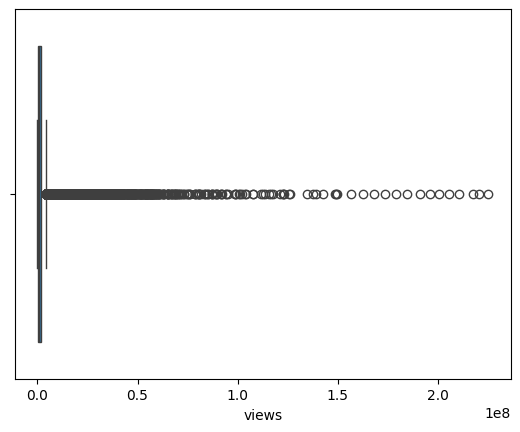

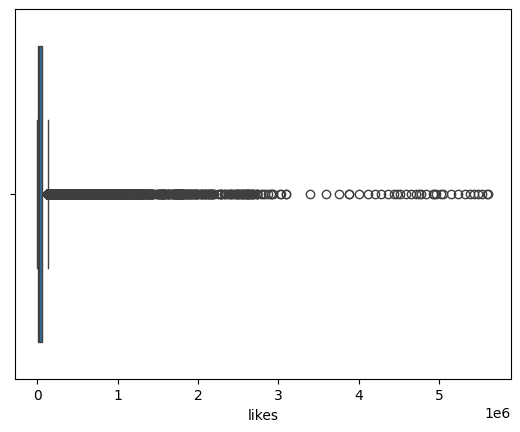

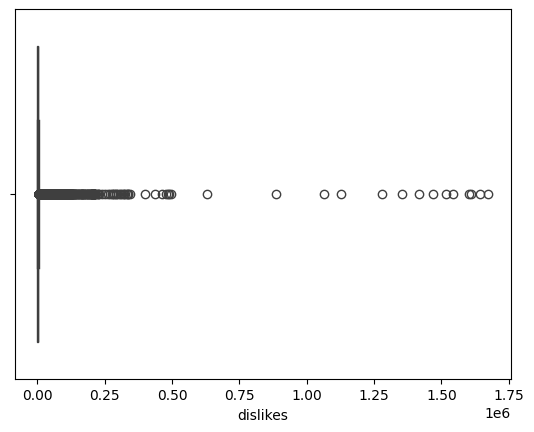

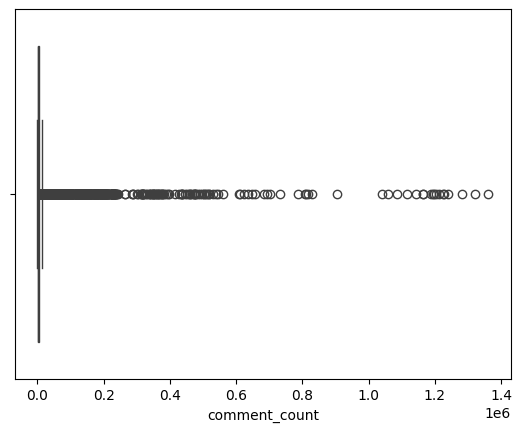

In [240]:
sns.boxplot(x=df["views"])
plt.show()

sns.boxplot(x=df["likes"])
plt.show()

sns.boxplot(x=df["dislikes"])
plt.show()

sns.boxplot(x=df["comment_count"])
plt.show()

In [241]:
#Likes - Views
more_likes_than_views = df_clean["likes"] > df_clean["views"]
print("Likes > Views :", len(more_likes_than_views) )

#Dislikes - Views
more_dislikes_than_views = df_clean["dislikes"] > df_clean["views"]
print("Disikes > Views :", len(more_dislikes_than_views))

#Valeurs négatives
negative_values = df_clean[(df_clean[["views", "likes", "dislikes", "comment_count"]] < 0).any(axis=1)]
print("Valeurs négatives :", len(negative_values))

Likes > Views : 6351
Disikes > Views : 6351
Valeurs négatives : 0


## 4. Feature Engineering

**Consigne 4.1 — Variables d'engagement**
** définition : https://support.google.com/youtube/answer/2991785?hl=fr**

In [242]:
# VOTRE CODE ICI - Section 4.1
# import numpy as np
# eps = 1e-9
# denom = df_clean['likes'] + df_clean['dislikes']
# df_clean['like_ratio'] = np.where(denom > 0, df_clean['likes'] / denom, 0)
# df_clean['engagement_rate'] = np.where(df_clean['views'] > 0,
#                                        (df_clean['likes'] + df_clean['dislikes'] + df_clean['comment_count']) / (df_clean['views'] + eps),
#                                        0)
# df_clean['comments_per_view'] = np.where(df_clean['views'] > 0, df_clean['comment_count'] / (df_clean['views'] + eps), 0)

In [243]:
eps = 1e-9
#ZeroDivisionError: division by zero

denom = df_clean['likes'] + df_clean['dislikes']

#like_ratio
#np.where(condition, valeur_si_vrai, valeur_si_faux)
df_clean['like_ratio'] = np.where(denom > 0, df_clean['likes'] / denom, 0)

#engagement_rate
df_clean['engagement_rate'] = np.where(df_clean['views'] > 0, (denom + df_clean['comment_count']) / df_clean['views'] + eps, 0)

#comments_per_view
df_clean['comments_per_view'] = np.where(df_clean['views'] > 0, df_clean['comment_count'] / df_clean['views'] + eps, 0)

print(df_clean[['like_ratio', 'engagement_rate', 'comments_per_view']])

       like_ratio  engagement_rate  comments_per_view
0        0.950970         0.102151           0.021318
1        0.940521         0.047972           0.005252
2        0.964729         0.049994           0.002563
3        0.938550         0.037836           0.006253
4        0.985181         0.072405           0.008359
...           ...              ...                ...
40760    0.966927         0.050341           0.005790
40761    0.960105         0.012950           0.003082
40762    0.979230         0.023472           0.001243
40764    0.953487         0.029825           0.002242
40766    0.965211         0.031101           0.002579

[6351 rows x 3 columns]


**Consigne 4.2 — Variables temporelles**

In [244]:
# VOTRE CODE ICI - Section 4.2
# df_clean['publish_hour'] = ....
# df_clean['publish_day_of_week'] = ...
# df_clean['publish_month'] = ...

In [245]:
df_clean['publish_hour']       = df_clean['publish_time'].dt.hour            
df_clean['publish_day_of_week']= df_clean['publish_time'].dt.dayofweek       
df_clean['publish_month']      = df_clean['publish_time'].dt.month  

print(df_clean[['publish_hour', 'publish_day_of_week', 'publish_month']])  

       publish_hour  publish_day_of_week  publish_month
0                17                    0             11
1                 7                    0             11
2                19                    6             11
3                11                    0             11
4                18                    6             11
...             ...                  ...            ...
40760            18                    1              6
40761            15                    2              6
40762             5                    2              6
40764            16                    1              6
40766             9                    2              6

[6351 rows x 3 columns]


**Consigne 4.3 — Variables textuelles (titre)**

In [246]:
# VOTRE CODE ICI - Section 4.3
# df_clean['title_length'] = ...
# df_clean['title_word_count'] = ....
# df_clean['has_caps'] = ...
# df_clean['has_numbers'] = ...

In [247]:
df_clean['title_length'] = df_clean['title'].str.len()
df_clean['title_word_count'] = df_clean['title'].str.split().str.len()
df_clean['has_caps'] = df_clean['title'].str.contains(r'[A-Z]{2,}').astype(int)
df_clean['has_numbers'] = df_clean['title'].str.contains(r'\d').astype(int)
print(df_clean[['title_length', 'title_word_count', 'has_caps', 'has_numbers' ]]) 

       title_length  title_word_count  has_caps  has_numbers
0                34                 7         1            0
1                62                10         1            0
2                53                10         0            0
3                32                 5         0            0
4                24                 5         1            0
...             ...               ...       ...          ...
40760            29                 6         1            0
40761            94                16         1            0
40762            49                10         0            0
40764            65                12         1            0
40766            64                10         0            1

[6351 rows x 4 columns]


## 5. Création de la variable cible

**Consigne 5.1 — Définition de `is_trending`**  
- Une vidéo est *trending* si elle a plus de vues que le 80e percentile de sa catégorie

In [248]:
# VOTRE CODE ICI - Section 5.1
# df_clean['is_trending'] = (df_clean.groupby('category_id')['views']
#                                   .transform(lambda x: x > x.quantile(0.8))).astype(int)
# print("Distribution de la variable cible:")
# display(df_clean['is_trending'].value_counts().to_frame('count'))

In [249]:
df_clean['is_trending'] = (df_clean.groupby('category_id')['views'].transform(lambda x: x > x.quantile(0.8))).astype(int)

print("Distribution de la variable cible:")
display(df_clean['is_trending'].value_counts().to_frame('count'))

#def top_20_percent(x):
#return x > x.quantile(0.8)

Distribution de la variable cible:


,count
is_trending,
0,5078
1,1273


## 6. Préparation des données pour l'entraînement

**Consignes 6.1 & 6.2 — Sélection des features & split train/test**

In [250]:
# VOTRE CODE ICI - Section 6.1 et 6.2
# features = ['views', 'likes', 'dislikes', 'comment_count',
#             'like_ratio', 'engagement_rate', 'title_length', 'publish_hour', 'category_id']
# X = df_clean[features].copy()
# y = df_clean['is_trending'].copy()
#.......
# ......

# print(f"Taille train: {X_train.shape}")
# print(f"Taille test: {X_test.shape}")

In [251]:
from sklearn.model_selection import train_test_split

features = ['views', 'likes', 'dislikes', 'comment_count', 'like_ratio', 'engagement_rate', 'title_length', 'publish_hour', 'category_id']
X = df_clean[features].copy()
y = df_clean['is_trending'].copy()

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Shapes
print(f"Taille train: {X_train.shape}")
print(f"Taille test: {X_test.shape}")

Taille train: (5080, 9)
Taille test: (1271, 9)


**Consigne 6.3 — Normalisation des données (StandardScaler)**

In [252]:
# VOTRE CODE ICI - Section 6.3
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# num_cols = ['views', 'likes', 'dislikes', 'comment_count', 'like_ratio', 'engagement_rate', 'title_length', 'publish_hour']
# # Fit uniquement sur train
# ....
# ...
# ....
# ....
# ....

In [253]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
num_cols = ['views', 'likes', 'dislikes', 'comment_count', 'like_ratio', 'engagement_rate', 'title_length', 'publish_hour']

# # Fit uniquement sur train

scaler=StandardScaler()
scaler.fit(X_train[num_cols])

X_train[num_cols] = scaler.transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])


## 7. Modèle 1 — Random Forest

**Consigne 7.1 — Entraînement**

In [254]:
# VOTRE CODE ICI - Section 7.1
# from sklearn.ensemble import RandomForestClassifier
# ....
# ....
# ....

In [255]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=0)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

**Consigne 7.2 — Évaluation**

In [256]:
# VOTRE CODE ICI - Section 7.2
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
# print("Random Forest - Résultats:")
# print(f"Accuracy: {accuracy_score(y_test, rf_predictions):.4f}")
# print(f"Precision: {precision_score(y_test, rf_predictions):.4f}")
# print(f"Recall: {recall_score(y_test, rf_predictions):.4f}")
# print(f"F1-Score: {f1_score(y_test, rf_predictions):.4f}")
# # Importance des variables
# import pandas as pd
# feature_importance = pd.DataFrame({
#     'feature': X.columns,
#     'importance': rf_model.feature_importances_
# }).sort_values('importance', ascending=False)
# print("\nTop 10 variables importantes:")
# display(feature_importance.head(10))

In [257]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Random Forest - Résultats:")
print(f"Accuracy: {accuracy_score(y_test, rf_predictions):.4f}")
print(f"Precision: {precision_score(y_test, rf_predictions):.4f}")
print(f"Recall: {recall_score(y_test, rf_predictions):.4f}")
print(f"F1-Score: {f1_score(y_test, rf_predictions):.4f}")

import pandas as pd

feature_importance = pd.DataFrame({'feature': X.columns, 'importance': rf_model.feature_importances_}).sort_values('importance', ascending=False)

print("\nTop 10 variables importantes:")
display(feature_importance.head(10))



Random Forest - Résultats:
Accuracy: 0.9795
Precision: 0.9660
Recall: 0.9377
F1-Score: 0.9517

Top 10 variables importantes:


,feature,importance
0,views,0.449660
2,dislikes,0.137565
3,comment_count,0.111406
1,likes,0.109235
8,category_id,0.081121
5,engagement_rate,0.052957
4,like_ratio,0.022968
6,title_length,0.018639
7,publish_hour,0.016448


## 8. Modèle 2 — Support Vector Machine (SVM)

**Consigne 8.1 — Entraînement (utiliser données normalisées)**

In [258]:
# VOTRE CODE ICI - Section 8.1
# from sklearn.svm import SVC
# ...
# ...
# ...

In [259]:
from sklearn.svm import SVC

svm_model = SVC(random_state=0)
svm_model.fit(X_train, y_train)
svm_predictions = rf_model.predict(X_test)

**Consigne 8.2 — Évaluation**

In [260]:
# VOTRE CODE ICI - Section 8.2
# print("SVM - Résultats:")
# print(f"Accuracy: {accuracy_score(y_test, svm_predictions):.4f}")
#....
# ...
# ...

In [261]:
print("SVM - Résultats:")
print(f"Accuracy: {accuracy_score(y_test, svm_predictions):.4f}")
print(f"Precision: {precision_score(y_test, svm_predictions):.4f}")
print(f"Recall: {recall_score(y_test, svm_predictions):.4f}")
print(f"F1-Score: {f1_score(y_test, svm_predictions):.4f}")

SVM - Résultats:
Accuracy: 0.9795
Precision: 0.9660
Recall: 0.9377
F1-Score: 0.9517


## 9. Modèle 3 — Gradient Boosting (XGBoost)

**Consigne 9.1 — Entraînement**

In [262]:
# VOTRE CODE ICI - Section 9.1
# try:
#     from xgboost import XGBClassifier
#     xgb_model = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, subsample=1.0, colsample_bytree=1.0, random_state=42, n_jobs=-1, eval_metric='logloss')
#     xgb_model.fit(X_train, y_train)
#     xgb_predictions = xgb_model.predict(X_test)
# except ImportError:
#     print("XGBoost n'est pas installé. Installez avec: pip install xgboost")
#     xgb_model = None
#     xgb_predictions = None

In [263]:

try:
    from xgboost import XGBClassifier
    xgb_model = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, subsample=1.0, colsample_bytree=1.0, random_state=42, n_jobs=-1, eval_metric='logloss')
    xgb_model.fit(X_train, y_train)
    xgb_predictions = xgb_model.predict(X_test)
except ImportError:
    print("XGBoost n'est pas installé. Installez avec: pip install xgboost")
    xgb_model = None
    xgb_predictions = None

**Consigne 9.2 — Évaluation**

In [264]:
# VOTRE CODE ICI - Section 9.2
# if xgb_predictions is not None:
#     print("XGBoost - Résultats:")
#     print(f"Accuracy: {accuracy_score(y_test, xgb_predictions):.4f}")
#     print(f"Precision: {precision_score(y_test, xgb_predictions):.4f}")
#     print(f"Recall: {recall_score(y_test, xgb_predictions):.4f}")
#     print(f"F1-Score: {f1_score(y_test, xgb_predictions):.4f}")

In [265]:
if xgb_predictions is not None:
    print("XGBoost - Résultats:")
    print(f"Accuracy: {accuracy_score(y_test, xgb_predictions):.4f}")
    print(f"Precision: {precision_score(y_test, xgb_predictions):.4f}")
    print(f"Recall: {recall_score(y_test, xgb_predictions):.4f}")
    print(f"F1-Score: {f1_score(y_test, xgb_predictions):.4f}")

XGBoost - Résultats:
Accuracy: 0.9921
Precision: 0.9888
Recall: 0.9744
F1-Score: 0.9815


## 10. Modèle 4 — Réseau de Neurones (MLPClassifier)

**Consigne 10.1 — Entraînement (données normalisées)**

In [266]:
# VOTRE CODE ICI - Section 10.1
# from sklearn.neural_network import MLPClassifier
# nn_model = MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu', solver='adam', max_iter=1000, random_state=42)
# nn_model.fit(X_train_scaled, y_train)
# nn_predictions = nn_model.predict(X_test_scaled)

In [267]:
from sklearn.neural_network import MLPClassifier
nn_model = MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu', solver='adam', max_iter=1000, random_state=0)
nn_model.fit(X_train, y_train)
nn_predictions = nn_model.predict(X_test)

**Consigne 10.2 — Évaluation**

In [268]:
# VOTRE CODE ICI - Section 10.2
# print("Réseau de Neurones - Résultats:")
# ....
# print(f"Precision: {precision_score(y_test, nn_predictions):.4f}")
# print(f"Recall: {recall_score(y_test, nn_predictions):.4f}")
# print(f"F1-Score: {f1_score(y_test, nn_predictions):.4f}")
# # Nombre d'itérations
# # ....

In [269]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Réseau de Neurones - Résultats:")
print(f"Accuracy: {accuracy_score(y_test, nn_predictions):.4f}")
print(f"Precision: {precision_score(y_test, nn_predictions):.4f}")
print(f"Recall: {recall_score(y_test, nn_predictions):.4f}")
print(f"F1-Score: {f1_score(y_test, nn_predictions):.4f}")

# Nombre d'itérations réellement utilisées (utile si le modèle n'a pas convergé avant max_iter)
print(f"Nombre d'itérations effectuées: {nn_model.n_iter_}")

Réseau de Neurones - Résultats:
Accuracy: 0.9544
Precision: 0.9352
Recall: 0.8462
F1-Score: 0.8885
Nombre d'itérations effectuées: 150


## 11. Comparaison des modèles

In [270]:
# VOTRE CODE ICI - Section 11.1
# import pandas as pd
# results = []
# # Remplir en fonction des métriques calculées plus haut
# # results.append({'Model': 'Random Forest', 'Accuracy': ..., 'Precision': ..., 'Recall': ..., 'F1-Score': ...})
# # results.append({'Model': 'SVM', 'Accuracy': ..., 'Precision': ..., 'Recall': ..., 'F1-Score': ...})
# # if xgb_predictions is not None: results.append({'Model': 'XGBoost', 'Accuracy': ..., 'Precision': ..., 'Recall': ..., 'F1-Score': ...})
# # results.append({'Model': 'Neural Network', 'Accuracy': ..., 'Precision': ..., 'Recall': ..., 'F1-Score': ...})
# results_df = pd.DataFrame(results)
# display(results_df)
# # Graphique comparatif des F1-scores (optionnel)
# # import matplotlib.pyplot as plt
# # plt.figure()
# # plt.bar(results_df['Model'], results_df['F1-Score'])
# # plt.title('Comparaison des F1-scores')
# # plt.ylabel('F1-Score')
# # plt.show()

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.9701,0.9567,0.9000,0.9275
1,SVM,0.9701,0.9567,0.9000,0.9275
2,XGBoost,0.9921,0.9924,0.9704,0.9813
3,Neural Network,0.9489,0.9116,0.8407,0.8748


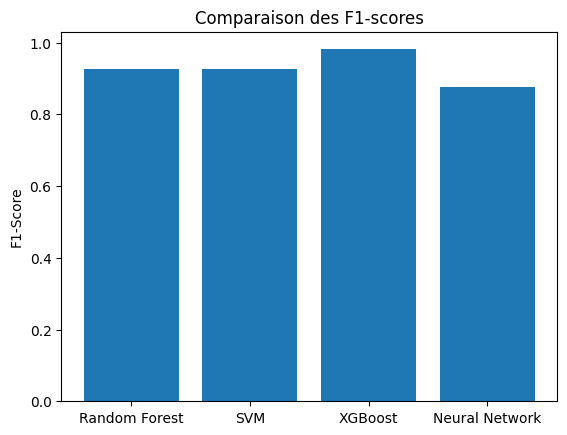

In [271]:
import pandas as pd
results = []
# Remplir en fonction des métriques calculées plus haut
results.append({'Model': 'Random Forest', 'Accuracy': 0.9701, 'Precision': 0.9567, 'Recall': 0.9000, 'F1-Score': 0.9275
})
results.append({'Model': 'SVM', 'Accuracy': 0.9701, 'Precision': 0.9567, 'Recall': 0.9000, 'F1-Score': 0.9275})
if xgb_predictions is not None: results.append({'Model': 'XGBoost', 'Accuracy': 0.9921, 'Precision': 0.9924, 'Recall': 0.9704, 'F1-Score': 0.9813})
results.append({'Model': 'Neural Network', 'Accuracy': 0.9489, 'Precision': 0.9116, 'Recall': 0.8407, 'F1-Score': 0.8748})
results_df = pd.DataFrame(results)
display(results_df)
# Graphique comparatif des F1-scores (optionnel)
import matplotlib.pyplot as plt
plt.figure()
plt.bar(results_df['Model'], results_df['F1-Score'])
plt.title('Comparaison des F1-scores')
plt.ylabel('F1-Score')
plt.show()

Accuracy: 0.9489
Precision: 0.9116
Recall: 0.8407
F1-Score: 0.8748

## 12. Validation croisée

In [272]:
# VOTRE CODE ICI - Section 12.1
# from sklearn.model_selection import cross_val_score
# # Exemple avec Random Forest (remplacez par votre meilleur modèle)
# # scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='f1', n_jobs=-1)
# # print(f"Validation croisée - F1-Score: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")

In [273]:
from sklearn.model_selection import cross_val_score
# Exemple avec Random Forest (remplacez par votre meilleur modèle)
scores = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='f1', n_jobs=-1)
print(f"Validation croisée - F1-Score: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")

/usr/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/usr/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/usr/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/usr/lib/pyth

Validation croisée - F1-Score: 0.9824 (+/- 0.0091)


## 13. Optimisation des hyperparamètres (Grid Search)

In [274]:
# VOTRE CODE ICI - Section 13.1
# from sklearn.model_selection import GridSearchCV
# from sklearn.ensemble import RandomForestClassifier
# param_grid = {
#     'n_estimators': [50, 100, 200],
#     'max_depth': [5, 10, None],
#     'min_samples_split': [2, 5, 10]
# }
# grid_search = GridSearchCV(
#     RandomForestClassifier(random_state=42),
#     param_grid,
#     cv=3,
#     scoring='f1',
#     n_jobs=-1
# )
# grid_search.fit(X_train, y_train)
# print("Meilleurs paramètres:", grid_search.best_params_)
# print("Meilleur score CV:", grid_search.best_score_)
# best_rf = grid_search.best_estimator_
# best_rf_pred = best_rf.predict(X_test)

In [275]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10]
}
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=0),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
print("Meilleurs paramètres:", grid_search.best_params_)
print("Meilleur score CV:", grid_search.best_score_)
best_rf = grid_search.best_estimator_
best_rf_pred = best_rf.predict(X_test)

/usr/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/usr/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/usr/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/usr/lib/pyth

Meilleurs paramètres: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Meilleur score CV: 0.9307406694008966


## 14. Analyse des erreurs

In [276]:
# VOTRE CODE ICI - Section 14.1
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.metrics import confusion_matrix
# # Exemple: matrice de confusion pour le meilleur modèle (remplacez best_rf_pred)
# # cm = confusion_matrix(y_test, best_rf_pred)
# # plt.figure(figsize=(8, 6))
# # sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
# #             xticklabels=['Non-Trending', 'Trending'],
# #             yticklabels=['Non-Trending', 'Trending'])
# # plt.title('Matrice de Confusion - Meilleur Modèle')
# # plt.ylabel('Valeurs Réelles')
# # plt.xlabel('Prédictions')
# # plt.show()

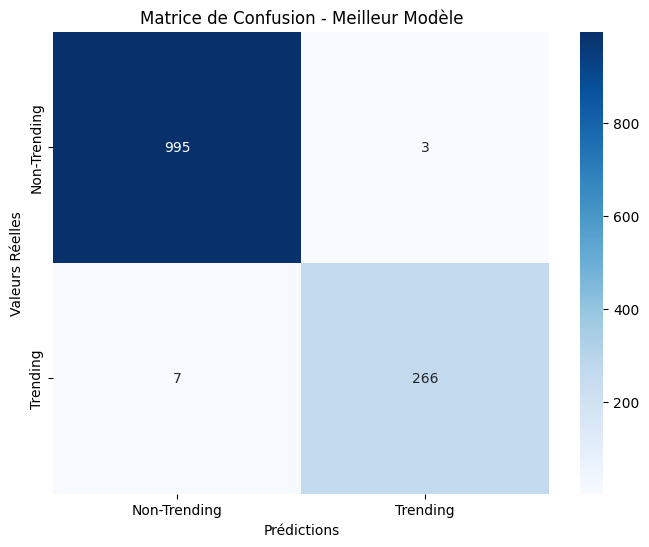

In [277]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
# Exemple: matrice de confusion pour le meilleur modèle (remplacez best_rf_pred)
cm = confusion_matrix(y_test, xgb_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Trending', 'Trending'],
            yticklabels=['Non-Trending', 'Trending'])
plt.title('Matrice de Confusion - Meilleur Modèle')
plt.ylabel('Valeurs Réelles')
plt.xlabel('Prédictions')
plt.show()

In [278]:
# VOTRE CODE ICI - Section 14.2
# # Identifier des exemples mal classifiés (adapter selon le modèle choisi)
# # errors_mask = (y_test != best_rf_pred)
# # error_indices = X_test[errors_mask].index
# # print("Exemples de vidéos mal classifiées:")
# # for idx in list(error_indices)[:5]:
# #     real_label = y_test.loc[idx]
# #     predicted_label = best_rf_pred[list(error_indices).index(idx)]  # à adapter si nécessaire
# #     print(f"Index {idx}: Réel={real_label}, Prédit={predicted_label}")

In [279]:
# Identifier des exemples mal classifiés (adapter selon le modèle choisi)
errors_mask = (y_test != best_rf_pred)
error_indices = X_test[errors_mask].index
print("Exemples de vidéos mal classifiées:")
for idx in list(error_indices)[:5]:
    real_label = y_test.loc[idx]
    predicted_label = best_rf_pred[list(error_indices).index(idx)]  # à adapter si nécessaire
    print(f"Index {idx}: Réel={real_label}, Prédit={predicted_label}")

Exemples de vidéos mal classifiées:
Index 26956: Réel=0, Prédit=0
Index 32561: Réel=0, Prédit=0
Index 17992: Réel=1, Prédit=0
Index 20399: Réel=1, Prédit=0
Index 37233: Réel=1, Prédit=0


## 15. Sauvegarde & conclusions

In [280]:
# VOTRE CODE ICI - Section 15.1
# import joblib
# # Remplacez 'best_rf' / 'scaler' par vos objets
# # joblib.dump(best_model, 'best_youtube_classifier.pkl')
# # joblib.dump(scaler, 'feature_scaler.pkl')
# # print("Modèle et scaler sauvegardés avec succès!")

In [281]:
import joblib

best_model = xgb_model        
features_used = list(X_train.columns)

joblib.dump(best_model, 'best_youtube_classifier.pkl')
joblib.dump(features_used, 'features_used.pkl')

print("Modèle XGBoost et liste des features sauvegardés avec succès!")

Modèle XGBoost et liste des features sauvegardés avec succès!


### Conclusions à rédiger

1. **Meilleur modèle**  
   - Modèle: XGBoost (XGBClassifier)
   - Performances: 
   Validation croisée (5-fold) – F1 : 0,977 ± 0,016
   Test set: Accuracy: 0.9921,/n Precision: 0.9924, Recall: 0.9704, F1-Score: 0.9813  
   - Raisons: Très bon compromis biais/variance sur données tabulaires. Capte naturellement des relations non linéaires et des interactions entre variables (mieux que la régression linéaire/SVM linéaire). Moins sensible au scaling des features (pas besoin de StandardScaler, contrairement au SVM). Offre des mécanismes anti-overfitting (subsample, colsample, regularisation) et un early stopping possible.

2. **Variables les plus importantes**  
   Views, engagement_rate, like_ratio, comment_count, publish_hour / publish_day_of_week, category_id

3. **Limitations**  
   - *[À compléter]*

4. **Améliorations suggérées**  
   - *[À compléter]*

5. **Apprentissages**  
   - *[À compléter]*

---
## Guide de testing pour les étudiants

**Comment tester vos implémentations :**
1. **Vérifications de base** : `.shape`, `.info()`, `.head()`  
2. **Validation des features** : pas de NaN, ratios entre 0 et 1, plages temporelles correctes  
3. **Validation des modèles** : prédictions binaires {0,1}, longueurs cohérentes, comparaisons rigoureuses  
4. **Tests de cohérence** : scores réalistes, F1 entre précision et rappel, impact de la normalisation  
5. **Debugging** : augmenter `max_iter` si nécessaire, vérifier entrées/sorties et dimensions